# EDA: UPF Energy Profiling â€” Feature Discovery

This notebook explores `data/processed/features.csv` produced by the featurize pipeline stage.

**Goals:**
1. Understand distributions of features and targets (DPDK vs OAI)
2. Identify correlations between traffic features and power consumption
3. Validate that feature engineering is sensible (no data leakage, no artefacts)
4. Inform modelling decisions (which target? which features matter?)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.1)
plt.rcParams["figure.figsize"] = (14, 5)

df = pd.read_csv("../data/processed/features.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (8781, 44)


,delay_variation_jitter_average_dn__avg_us,delay_variation_jitter_average_ran__avg_us,downlink_one_way_delay_distribution__weighted_mean_delay_us,downlink_one_way_delay_distribution__total_packets,downlink_one_way_delay_distribution__high_delay_frac,gtpu_kbitss_dn__kbits_rx_s,gtpu_kbitss_dn__kbits_tx_s,gtpu_kbitss_ngran__gtpu_kbits_rx_s,gtpu_kbitss_ngran__gtpu_kbits_tx_s,gtpu_packets_dn__packets_lost_delta,...,throughput_gbps_roll_std_30s,throughput_gbps_roll_max_30s,throughput_gbps_diff,avg_packet_size_bytes,dn_ngran_throughput_ratio,cpu_per_watt,l2l3_overhead_ratio,uplink_data_one_way_delay_distribution__delay_power_product,downlink_one_way_delay_distribution__delay_power_product,is_dpdk
0,1447.0,52.0,62.5,2.0,0.0,10.0,10.0,9.0,9.0,0.0,...,0.000007,0.00001,0.00001,1875.0,1.111111,1.295673,2.1016,0.0,0.0,1
1,579.0,22.0,62.5,5.0,0.0,10.0,10.0,11.0,10.0,0.0,...,0.000006,0.00001,0.00000,1250.0,0.909091,1.295971,2.1024,0.0,0.0,1
2,364.0,15.0,62.5,8.0,0.0,10.0,10.0,9.0,10.0,0.0,...,0.000005,0.00001,0.00000,1250.0,1.111111,1.296310,2.1016,0.0,0.0,1
3,267.0,13.0,62.5,11.0,0.0,10.0,10.0,9.0,9.0,0.0,...,0.000004,0.00001,0.00000,1250.0,1.111111,1.297012,2.1016,0.0,0.0,1
4,210.0,11.0,62.5,14.0,0.0,10.0,10.0,11.0,10.0,0.0,...,0.000004,0.00001,0.00000,1250.0,0.909091,1.295295,2.1024,0.0,0.0,1


## 1. Dataset Overview

In [2]:
# Split by variant for side-by-side comparisons throughout
dpdk = df[df["is_dpdk"] == 1]
oai  = df[df["is_dpdk"] == 0]

print(f"DPDK rows: {len(dpdk):,}   |   OAI rows: {len(oai):,}")
print(f"\nColumns ({len(df.columns)}):")
for i, c in enumerate(df.columns):
    print(f"  {i:2d}. {c}")

print(f"\nMissing values per column:")
missing = df.isna().sum()
print(missing[missing > 0].to_string() if missing.any() else "  None")

DPDK rows: 4,388   |   OAI rows: 4,393

Columns (44):
   0. delay_variation_jitter_average_dn__avg_us
   1. delay_variation_jitter_average_ran__avg_us
   2. downlink_one_way_delay_distribution__weighted_mean_delay_us
   3. downlink_one_way_delay_distribution__total_packets
   4. downlink_one_way_delay_distribution__high_delay_frac
   5. gtpu_kbitss_dn__kbits_rx_s
   6. gtpu_kbitss_dn__kbits_tx_s
   7. gtpu_kbitss_ngran__gtpu_kbits_rx_s
   8. gtpu_kbitss_ngran__gtpu_kbits_tx_s
   9. gtpu_packets_dn__packets_lost_delta
  10. gtpu_packets_dn__packets_rx_delta
  11. gtpu_packets_dn__packets_tx_delta
  12. gtpu_packets_ngran__gtpu_packets_rx_delta
  13. gtpu_packets_ngran__gtpu_packets_tx_delta
  14. gtpu_packets_ngran__lost_packets_delta
  15. one_way_delay_average_dn__average
  16. one_way_delay_average_ran__average
  17. uplink_data_one_way_delay_distribution__weighted_mean_delay_us
  18. uplink_data_one_way_delay_distribution__total_packets
  19. uplink_data_one_way_delay_distribution__

In [3]:
# Summary statistics — split by variant
desc = df.groupby("is_dpdk").describe().T
desc.columns = desc.columns.map({0: "OAI", 1: "DPDK"})
desc.round(3)


is_dpdk                                                        OAI      DPDK
delay_variation_jitter_average_dn__avg_us          count  4393.000  4388.000
                                                   mean      7.189     8.742
                                                   std      12.007    48.197
                                                   min       1.000     0.000
                                                   25%       2.000     0.000
...                                                            ...       ...
downlink_one_way_delay_distribution__delay_powe... min       0.000     0.000
                                                   25%       0.000     0.000
                                                   50%       0.000     0.000
                                                   75%       1.448     0.000
                                                   max       3.910     0.833

[344 rows x 2 columns]

## 2. Target Variable Distributions

We have four candidate targets. Understanding their distributions helps choose which to model.

| Target | Meaning |
|--------|---------|
| `power_watts` | Total UPF power consumption |
| `net_power_watts` | Power above idle baseline (marginal cost of traffic) |
| `sec_total` | Total power / throughput (J/Gb â€” true energy cost per bit) |
| `sec_net` | Net power / throughput (marginal energy per bit) |

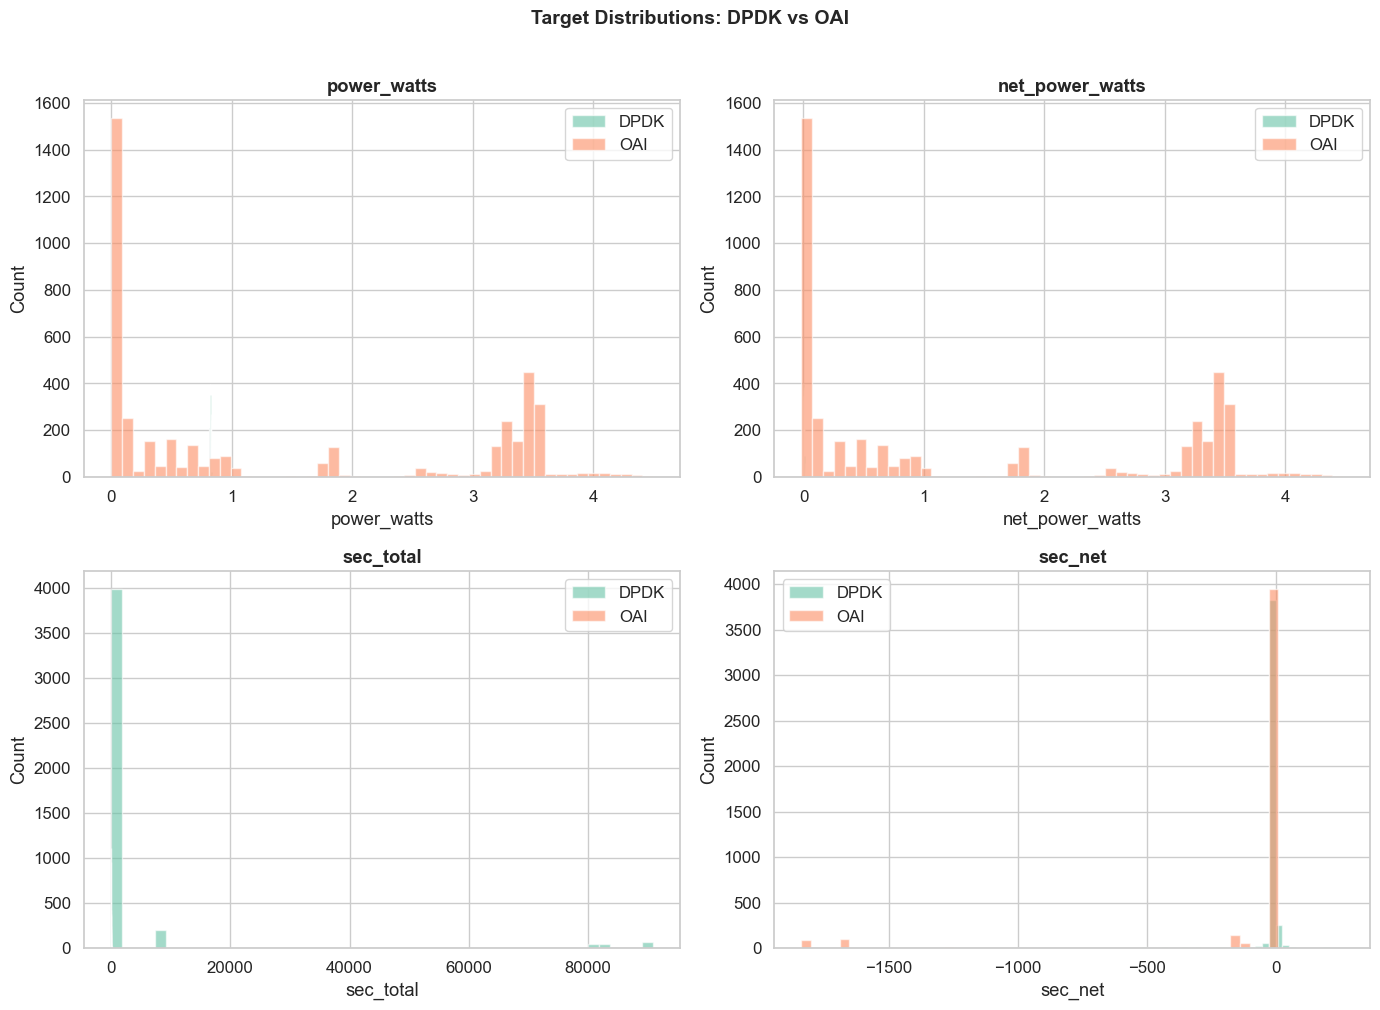

In [4]:
targets = ["power_watts", "net_power_watts", "sec_total", "sec_net"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, t in zip(axes.flat, targets):
    for label, subset, color in [("DPDK", dpdk, "C0"), ("OAI", oai, "C1")]:
        vals = subset[t].dropna()
        # Clip extreme SEC outliers for visibility
        if "sec" in t:
            q99 = vals.quantile(0.99)
            vals = vals[vals <= q99]
        ax.hist(vals, bins=50, alpha=0.6, label=label, color=color, edgecolor="white")
    ax.set_title(t, fontweight="bold")
    ax.set_xlabel(t)
    ax.set_ylabel("Count")
    ax.legend()

fig.suptitle("Target Distributions: DPDK vs OAI", fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

In [5]:
# Quantitative comparison of targets by variant
for t in targets:
    print(f"\n{'='*60}")
    print(f"  {t}")
    print(f"{'='*60}")
    for label, subset in [("DPDK", dpdk), ("OAI", oai)]:
        s = subset[t].dropna()
        print(f"  {label:5s}:  mean={s.mean():12.4f}  std={s.std():12.4f}  "
              f"min={s.min():12.4f}  median={s.median():12.4f}  max={s.max():12.4f}")


  power_watts
  DPDK :  mean=      0.8206  std=      0.0046  min=      0.8071  median=      0.8206  max=      0.8590
  OAI  :  mean=      1.4350  std=      1.5269  min=      0.0000  median=      0.5426  max=      4.4973

  net_power_watts
  DPDK :  mean=      0.0013  std=      0.0046  min=     -0.0121  median=      0.0013  max=      0.0397
  OAI  :  mean=      1.4185  std=      1.5269  min=     -0.0166  median=      0.5261  max=      4.4808

  sec_total
  DPDK :  mean=   4371.6773  std=  18014.8274  min=      0.1633  median=     10.3858  max=  92077.0450
  OAI  :  mean=      7.6289  std=     20.2808  min=      0.0000  median=      8.1434  max=    448.2151

  sec_net
  DPDK :  mean=     -3.1179  std=     87.5777  min=  -1048.2168  median=      0.0016  max=   1045.5398
  OAI  :  mean=    -80.8626  std=    360.5612  min=  -1839.8964  median=      5.0501  max=    165.8609


## 3. Power vs Throughput â€” The Core Relationship

This is the most important plot for the research: how does UPF power consumption scale with traffic load?

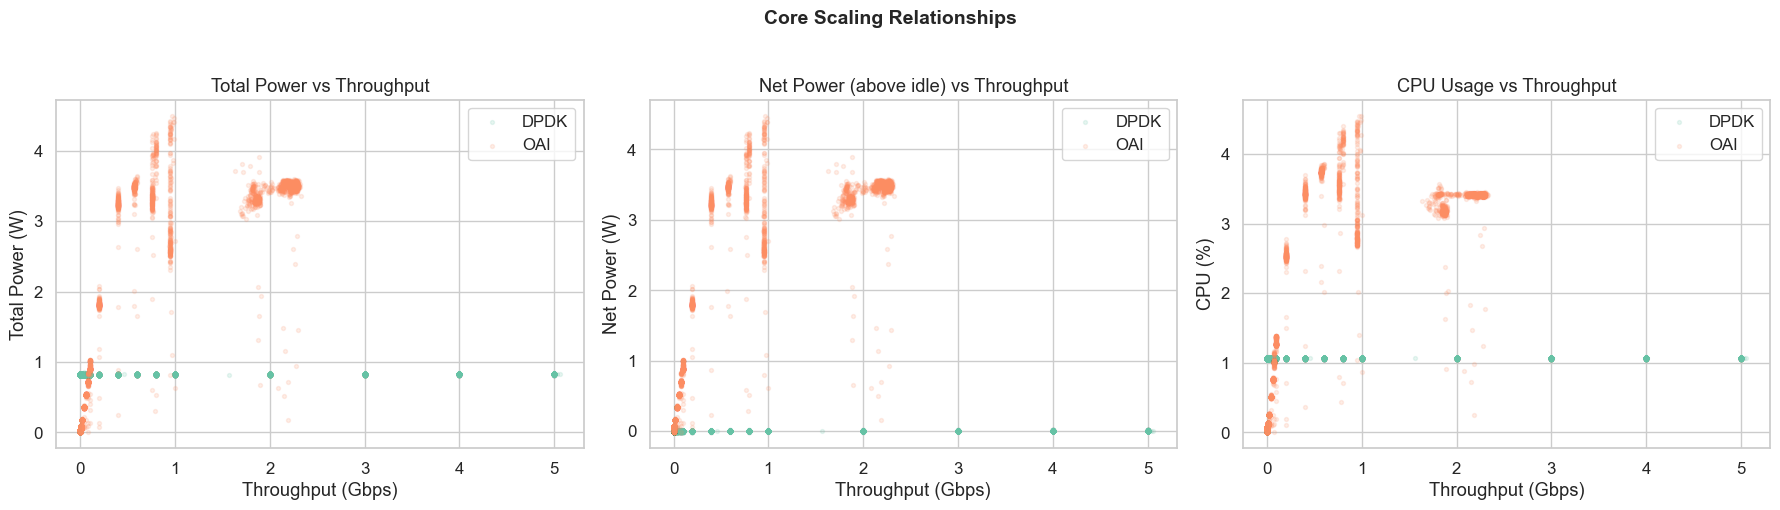

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Total power vs throughput
ax = axes[0]
for label, subset, color in [("DPDK", dpdk, "C0"), ("OAI", oai, "C1")]:
    ax.scatter(subset["throughput_gbps"], subset["power_watts"],
               alpha=0.15, s=8, label=label, color=color)
ax.set_xlabel("Throughput (Gbps)")
ax.set_ylabel("Total Power (W)")
ax.set_title("Total Power vs Throughput")
ax.legend()

# Net power vs throughput
ax = axes[1]
for label, subset, color in [("DPDK", dpdk, "C0"), ("OAI", oai, "C1")]:
    ax.scatter(subset["throughput_gbps"], subset["net_power_watts"],
               alpha=0.15, s=8, label=label, color=color)
ax.set_xlabel("Throughput (Gbps)")
ax.set_ylabel("Net Power (W)")
ax.set_title("Net Power (above idle) vs Throughput")
ax.legend()

# CPU vs throughput
ax = axes[2]
for label, subset, color in [("DPDK", dpdk, "C0"), ("OAI", oai, "C1")]:
    ax.scatter(subset["throughput_gbps"], subset["cpu_pct"],
               alpha=0.15, s=8, label=label, color=color)
ax.set_xlabel("Throughput (Gbps)")
ax.set_ylabel("CPU (%)")
ax.set_title("CPU Usage vs Throughput")
ax.legend()

fig.suptitle("Core Scaling Relationships", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

## 4. Correlation Heatmap

Which features are most correlated with the targets? This is the feature *discovery* question.

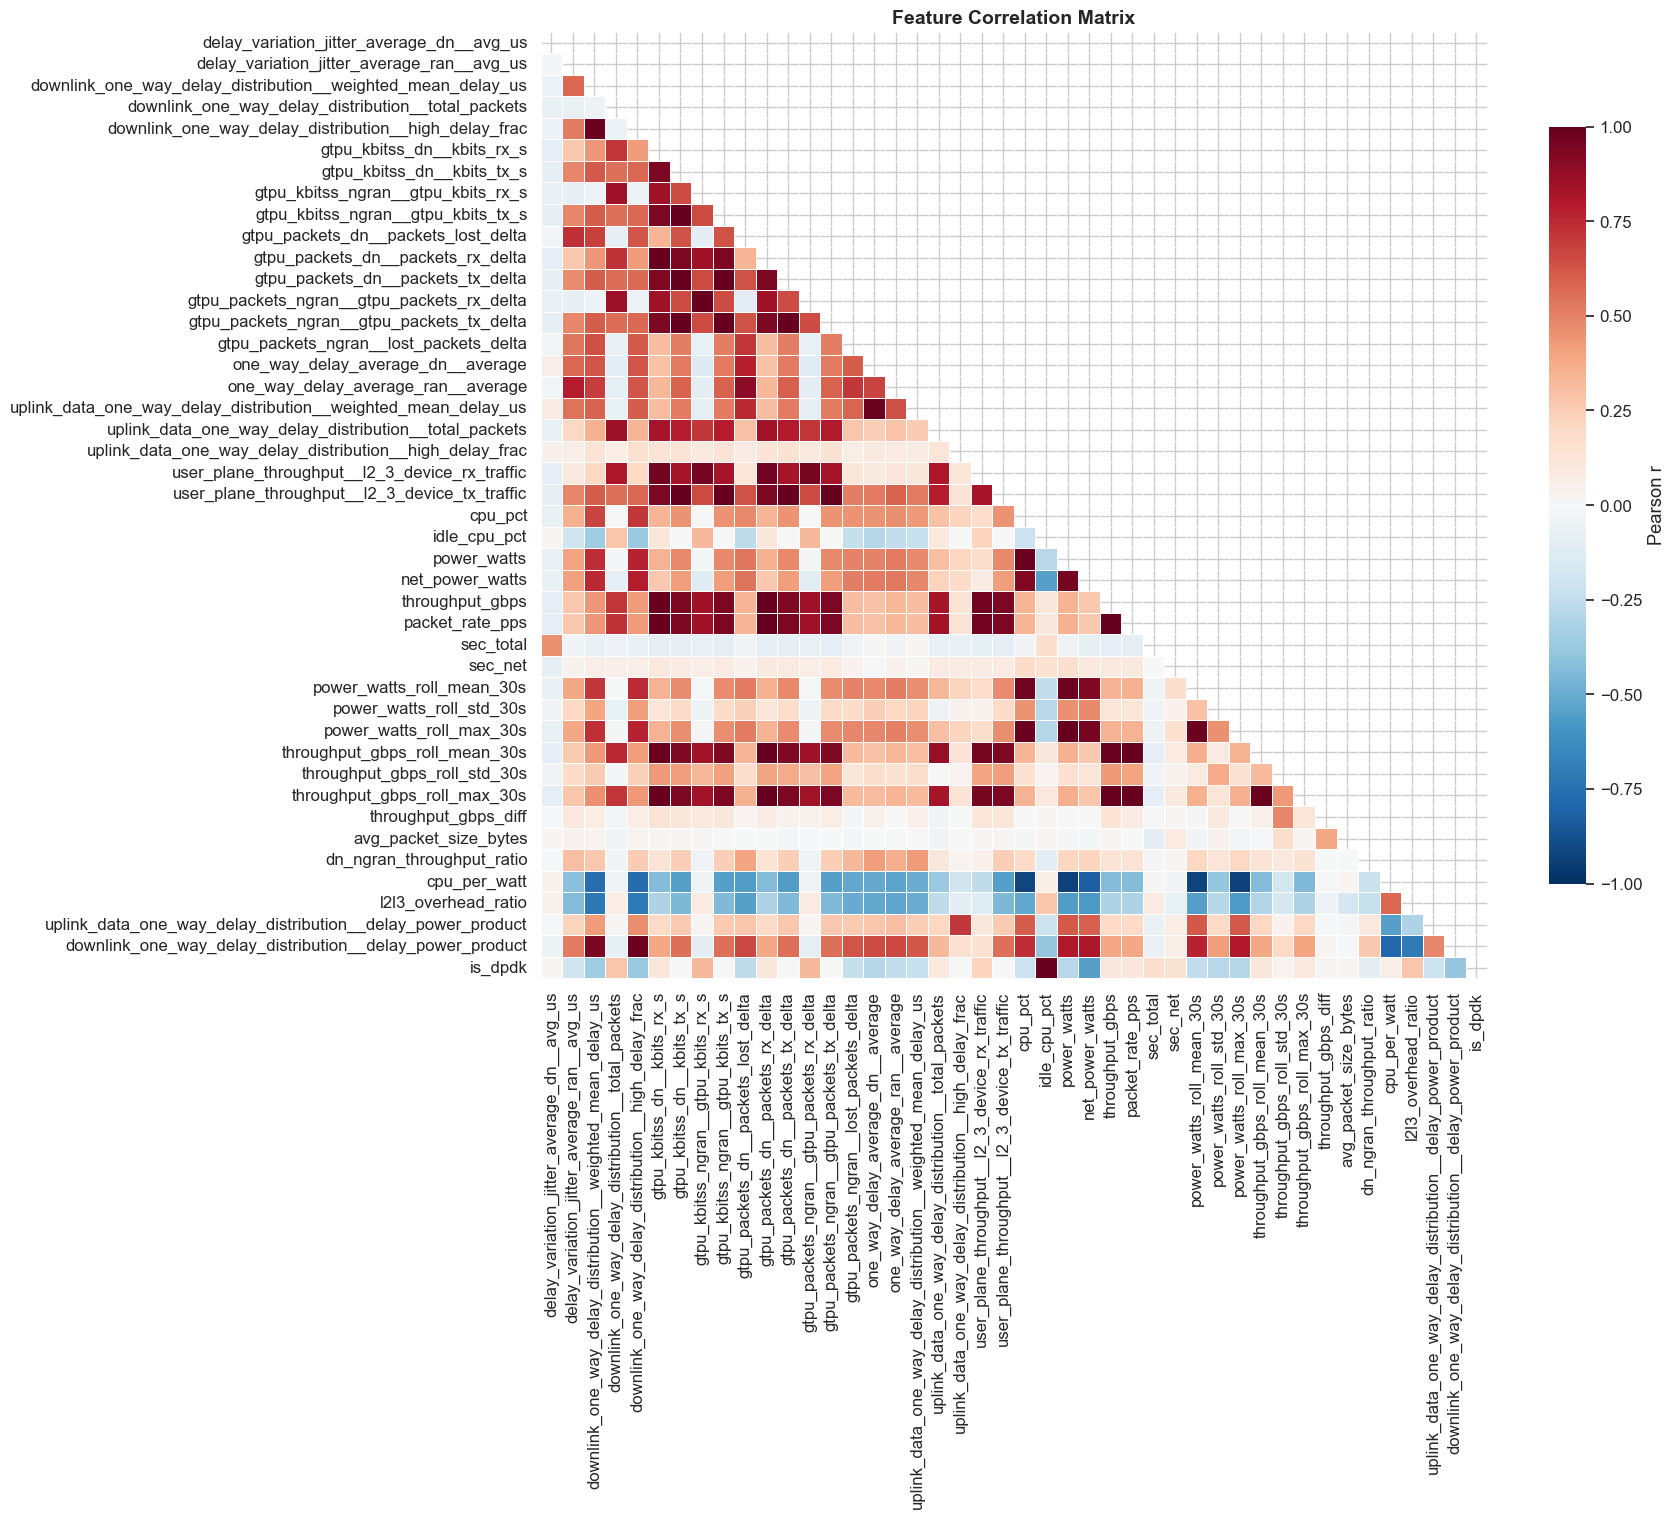

In [7]:
# Full correlation heatmap
numeric = df.select_dtypes(include="number")
corr = numeric.corr()

fig, ax = plt.subplots(figsize=(18, 15))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot=False, square=True, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.8, "label": "Pearson r"})
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

In [8]:
# Top correlations with each target â€” the key feature-discovery table
print("Top absolute correlations with each target:\n")
for t in targets:
    if t not in corr.columns:
        continue
    top = (corr[t]
           .drop(labels=targets, errors="ignore")  # exclude other targets
           .abs()
           .sort_values(ascending=False)
           .head(10))
    print(f"  {t}")
    print(f"  {'-'*50}")
    for feat, r in top.items():
        sign = "+" if corr.loc[feat, t] > 0 else "-"
        print(f"    {sign}{r:.3f}  {feat}")
    print()

Top absolute correlations with each target:

  power_watts
  --------------------------------------------------
    +0.998  power_watts_roll_max_30s
    +0.991  cpu_pct
    +0.982  power_watts_roll_mean_30s
    -0.936  cpu_per_watt
    +0.797  downlink_one_way_delay_distribution__delay_power_product
    +0.768  downlink_one_way_delay_distribution__high_delay_frac
    +0.735  downlink_one_way_delay_distribution__weighted_mean_delay_us
    +0.614  uplink_data_one_way_delay_distribution__delay_power_product
    -0.561  l2l3_overhead_ratio
    +0.535  gtpu_packets_dn__packets_lost_delta

  net_power_watts
  --------------------------------------------------
    +0.955  power_watts_roll_max_30s
    +0.930  power_watts_roll_mean_30s
    +0.929  cpu_pct
    -0.822  cpu_per_watt
    +0.814  downlink_one_way_delay_distribution__delay_power_product
    +0.783  downlink_one_way_delay_distribution__high_delay_frac
    +0.750  downlink_one_way_delay_distribution__weighted_mean_delay_us
    +0.600  

## 5. DPDK vs OAI â€” Per-Variant Correlations

The pooled correlation mixes two very different architectures. Let's check if the same features matter for both.

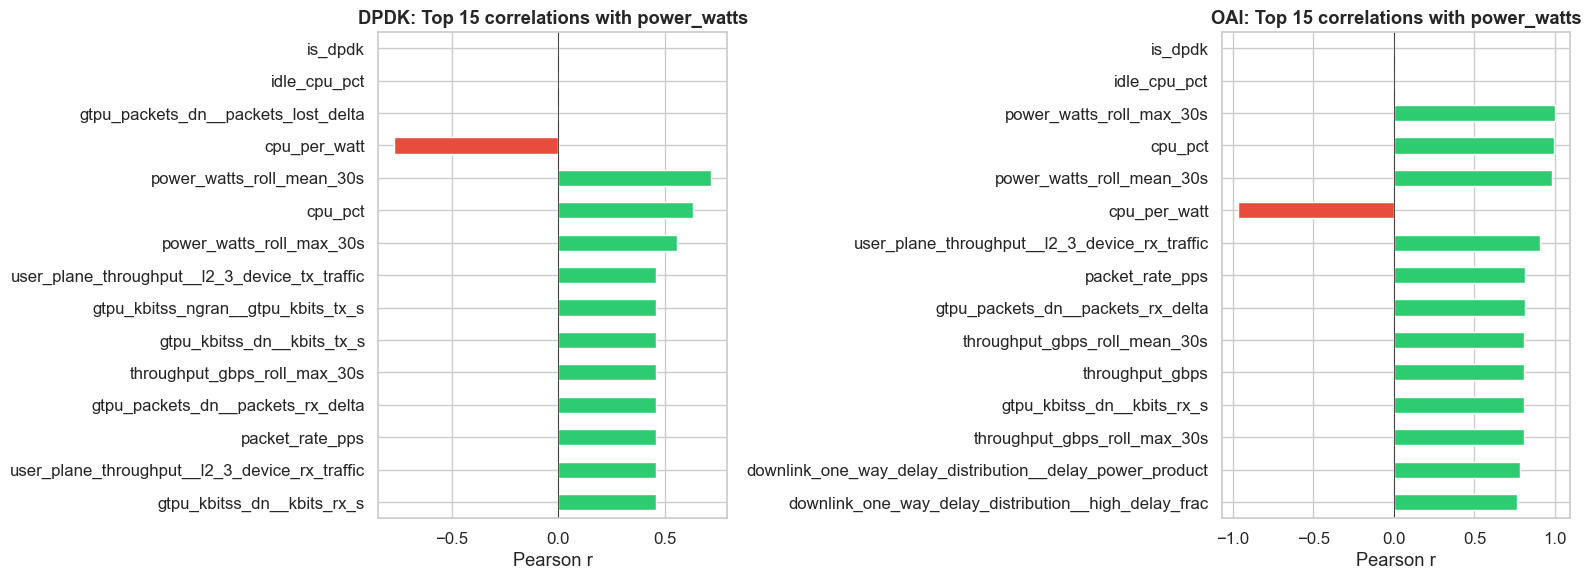

In [9]:
# Compare top-10 correlations per variant for power_watts
target = "power_watts"
features_only = [c for c in numeric.columns if c not in targets]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (label, subset) in zip(axes, [("DPDK", dpdk), ("OAI", oai)]):
    sub_corr = subset[features_only + [target]].corr()[target].drop(target)
    top10 = sub_corr.abs().sort_values(ascending=True).tail(15)
    colors = ["#e74c3c" if sub_corr[f] < 0 else "#2ecc71" for f in top10.index]
    top10_signed = pd.Series([sub_corr[f] for f in top10.index], index=top10.index)
    top10_signed.plot.barh(ax=ax, color=colors)
    ax.set_title(f"{label}: Top 15 correlations with {target}", fontweight="bold")
    ax.set_xlabel("Pearson r")
    ax.axvline(0, color="black", linewidth=0.5)

fig.tight_layout()
plt.show()

## 6. Temporal Dynamics â€” Power Traces Within Runs

Does power respond instantly to throughput changes, or is there a lag? Important for understanding if rolling features add value.

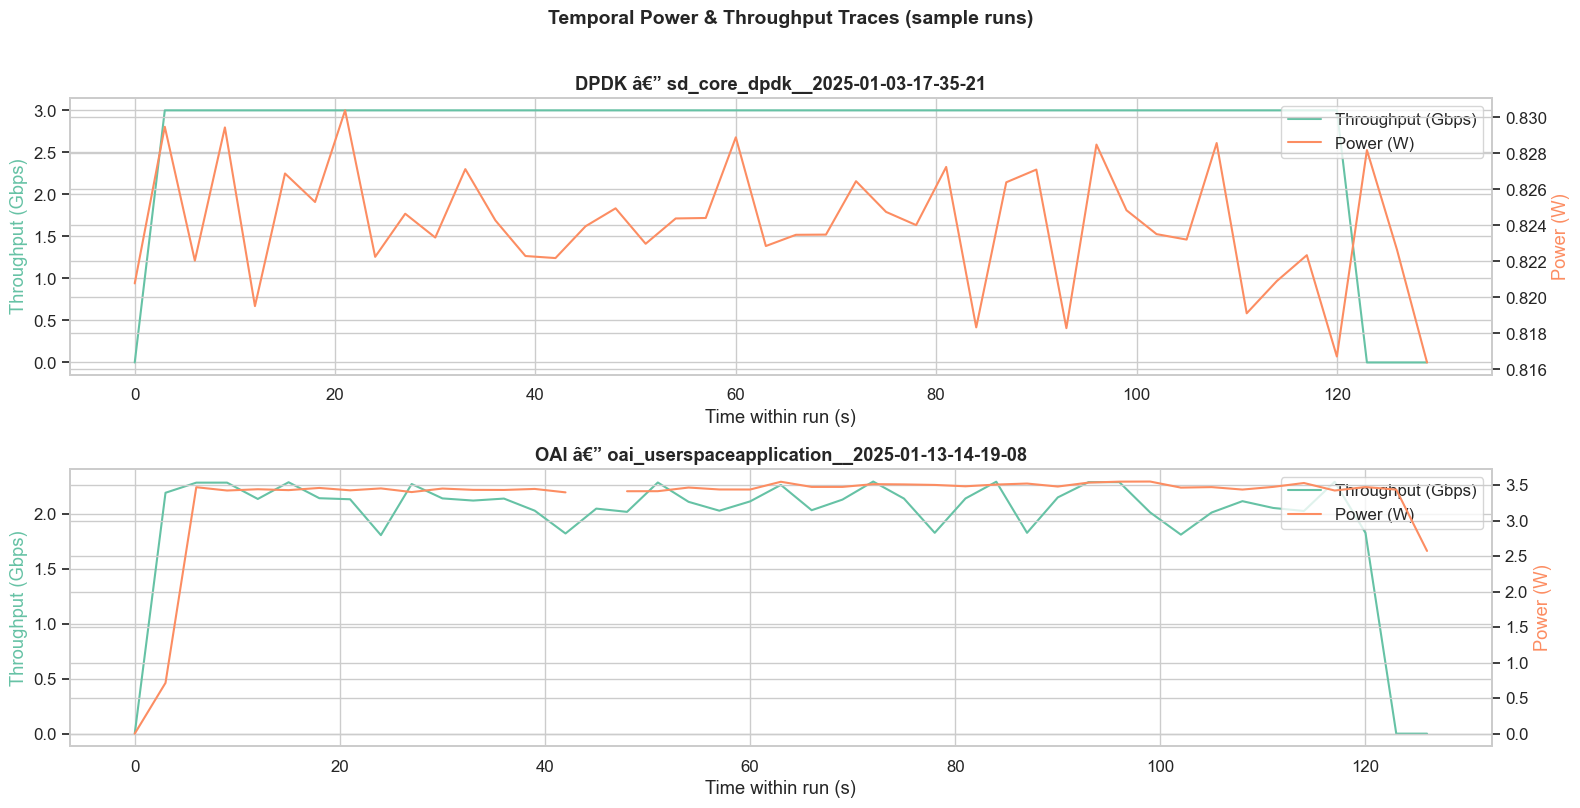

In [10]:
# Load merged.csv to get run_dir and timestamps for temporal plots
df_merged = pd.read_csv("../data/interim/merged.csv")

# Pick one high-traffic DPDK run and one OAI run for illustration
dpdk_runs = df_merged[df_merged["dataplane"] == "dpdk"]["run_dir"].unique()
oai_runs  = df_merged[df_merged["dataplane"] == "userspaceapplication"]["run_dir"].unique()

# Find runs with highest max throughput
def pick_run(subset, runs):
    best, best_tp = None, 0
    for r in runs[:20]:  # check first 20 for speed
        rdf = subset[subset["run_dir"] == r]
        tp = rdf["gtpu_kbitss_dn__kbits_rx_s"].max()
        if tp > best_tp:
            best, best_tp = r, tp
    return best

dpdk_run = pick_run(df_merged[df_merged["dataplane"]=="dpdk"], dpdk_runs)
oai_run  = pick_run(df_merged[df_merged["dataplane"]=="userspaceapplication"], oai_runs)

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=False)

for ax, (label, run_id) in zip(axes, [("DPDK", dpdk_run), ("OAI", oai_run)]):
    if run_id is None:
        ax.set_title(f"{label} — no runs found")
        continue
    rdf = df_merged[df_merged["run_dir"] == run_id].copy()
    rdf["t_sec"] = (rdf["Timestamp epoch ms"] - rdf["Timestamp epoch ms"].iloc[0]) / 1000
    
    ax_tp = ax
    ax_pw = ax.twinx()
    
    ax_tp.plot(rdf["t_sec"], rdf["gtpu_kbitss_dn__kbits_rx_s"] / 1e6,
               color="C0", linewidth=1.5, label="Throughput (Gbps)")
    ax_pw.plot(rdf["t_sec"], rdf["power_microwatts"] / 1e6,
               color="C1", linewidth=1.5, label="Power (W)")
    
    ax_tp.set_xlabel("Time within run (s)")
    ax_tp.set_ylabel("Throughput (Gbps)", color="C0")
    ax_pw.set_ylabel("Power (W)", color="C1")
    ax.set_title(f"{label} â€” {run_id}", fontweight="bold")
    
    lines1, labels1 = ax_tp.get_legend_handles_labels()
    lines2, labels2 = ax_pw.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

fig.suptitle("Temporal Power & Throughput Traces (sample runs)", fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()


## 7. Feature Distributions â€” Boxplots by Variant

Quick check for distributional differences between DPDK and OAI across all features.

C:\Users\Shima\AppData\Local\Temp\ipykernel_4840\3623054691.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)


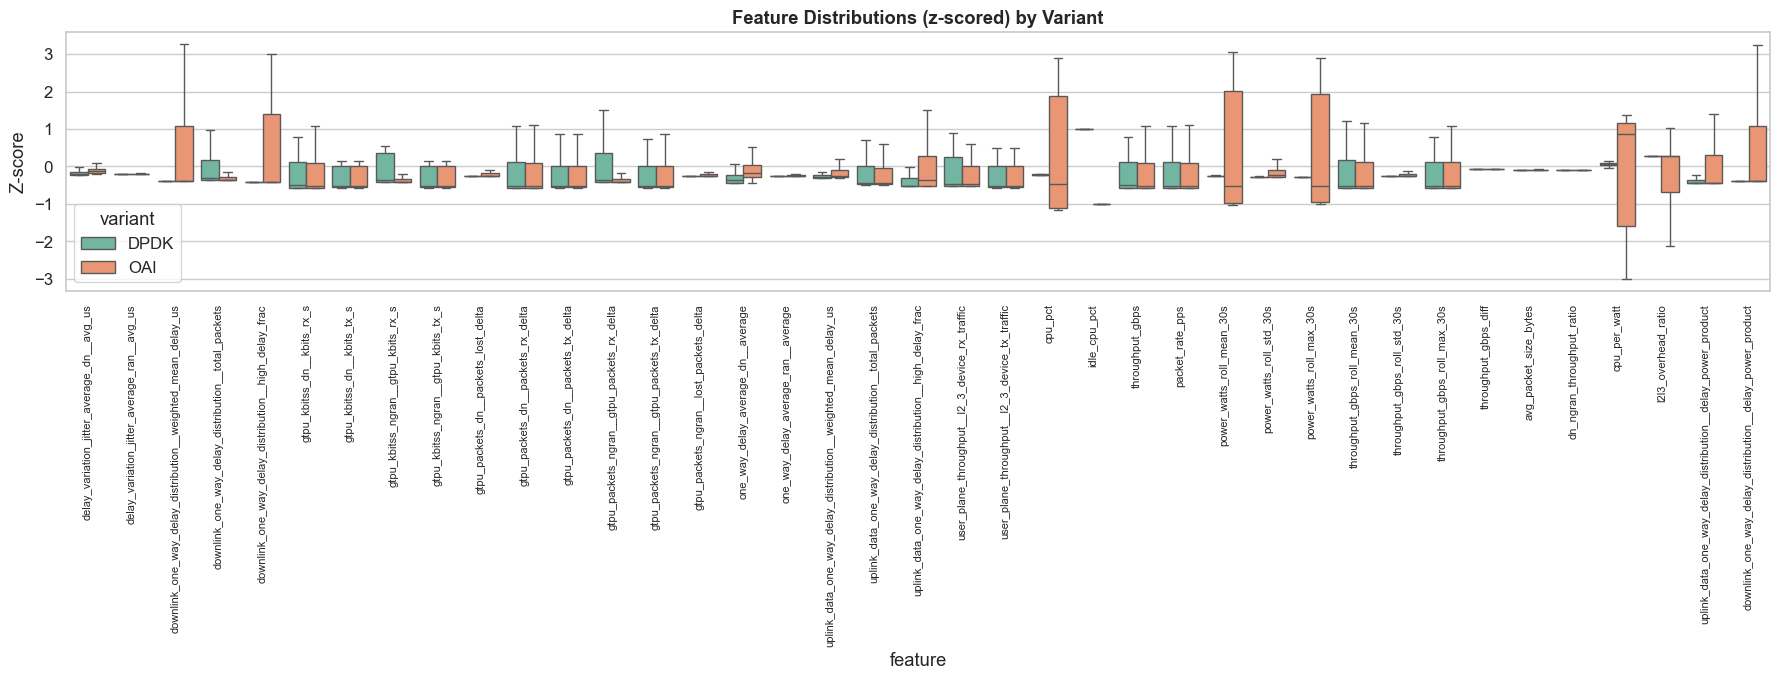

In [11]:
# Normalized boxplots (z-score) so features with different scales are comparable
plot_cols = [c for c in features_only if c != "is_dpdk"]

# Z-score normalize for visibility
zdf = df[plot_cols + ["is_dpdk"]].copy()
for c in plot_cols:
    s = zdf[c].std()
    if s > 0:
        zdf[c] = (zdf[c] - zdf[c].mean()) / s

melted = zdf.melt(id_vars="is_dpdk", var_name="feature", value_name="z_score")
melted["variant"] = melted["is_dpdk"].map({1: "DPDK", 0: "OAI"})

fig, ax = plt.subplots(figsize=(18, 7))
sns.boxplot(data=melted, x="feature", y="z_score", hue="variant",
            showfliers=False, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)
ax.set_title("Feature Distributions (z-scored) by Variant", fontweight="bold")
ax.set_ylabel("Z-score")
fig.tight_layout()
plt.show()

## 8. SEC Analysis â€” The DPDK Paradox

As discussed: DPDK has high idle power (poll-mode driver) so `sec_total` penalizes it, while `sec_net` rewards it. Let's visualize this directly.

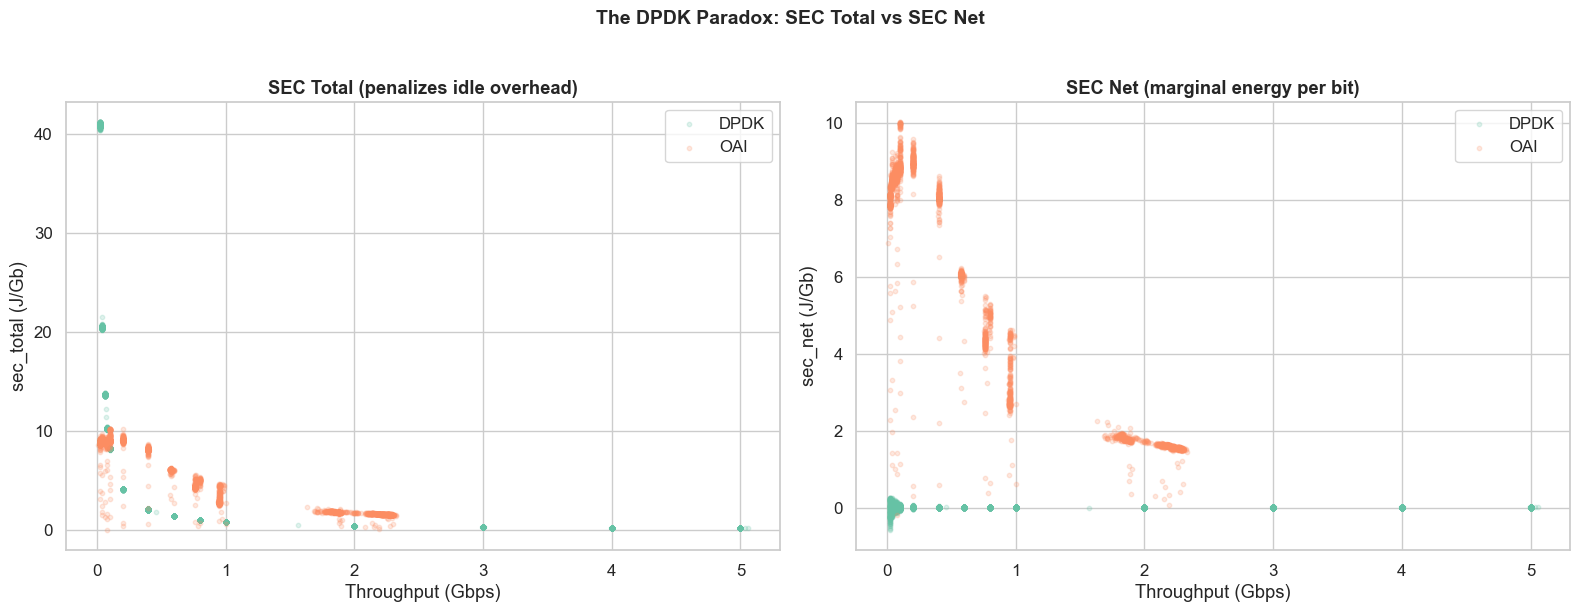


Median SEC at high throughput (>1 Gbps):
  DPDK:  sec_total=0.27 J/Gb  sec_net=0.0015 J/Gb  total_power=0.824 W
  OAI:  sec_total=1.61 J/Gb  sec_net=1.6073 J/Gb  total_power=3.478 W


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, sec_col, title in zip(axes,
        ["sec_total", "sec_net"],
        ["SEC Total (penalizes idle overhead)", "SEC Net (marginal energy per bit)"]):
    for label, subset, color in [("DPDK", dpdk, "C0"), ("OAI", oai, "C1")]:
        vals = subset[["throughput_gbps", sec_col]].dropna()
        # Clip extreme outliers at low throughput
        vals = vals[vals["throughput_gbps"] > 0.01]
        q99 = vals[sec_col].quantile(0.99)
        vals = vals[vals[sec_col] <= q99]
        ax.scatter(vals["throughput_gbps"], vals[sec_col],
                   alpha=0.2, s=10, label=label, color=color)
    ax.set_xlabel("Throughput (Gbps)")
    ax.set_ylabel(f"{sec_col} (J/Gb)")
    ax.set_title(title, fontweight="bold")
    ax.legend()

fig.suptitle("The DPDK Paradox: SEC Total vs SEC Net",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

# Quantify the paradox
print("\nMedian SEC at high throughput (>1 Gbps):")
for label, subset in [("DPDK", dpdk), ("OAI", oai)]:
    high = subset[subset["throughput_gbps"] > 1.0]
    if len(high) > 0:
        print(f"  {label}:  sec_total={high['sec_total'].median():.2f} J/Gb"
              f"  sec_net={high['sec_net'].median():.4f} J/Gb"
              f"  total_power={high['power_watts'].median():.3f} W")

## 9. Delay & Loss Analysis

Are delay and packet loss correlated with power? Congestion-induced retransmission or buffering could increase CPU/power.

Delay features: ['delay_variation_jitter_average_dn__avg_us', 'delay_variation_jitter_average_ran__avg_us', 'downlink_one_way_delay_distribution__weighted_mean_delay_us', 'downlink_one_way_delay_distribution__total_packets', 'downlink_one_way_delay_distribution__high_delay_frac', 'one_way_delay_average_dn__average', 'one_way_delay_average_ran__average', 'uplink_data_one_way_delay_distribution__weighted_mean_delay_us', 'uplink_data_one_way_delay_distribution__total_packets', 'uplink_data_one_way_delay_distribution__high_delay_frac', 'uplink_data_one_way_delay_distribution__delay_power_product', 'downlink_one_way_delay_distribution__delay_power_product']
Loss features: ['gtpu_packets_dn__packets_lost_delta', 'gtpu_packets_ngran__lost_packets_delta']
  DPDK: 0/4388 rows (0.0%) have packet loss
  OAI: 1435/4393 rows (32.7%) have packet loss


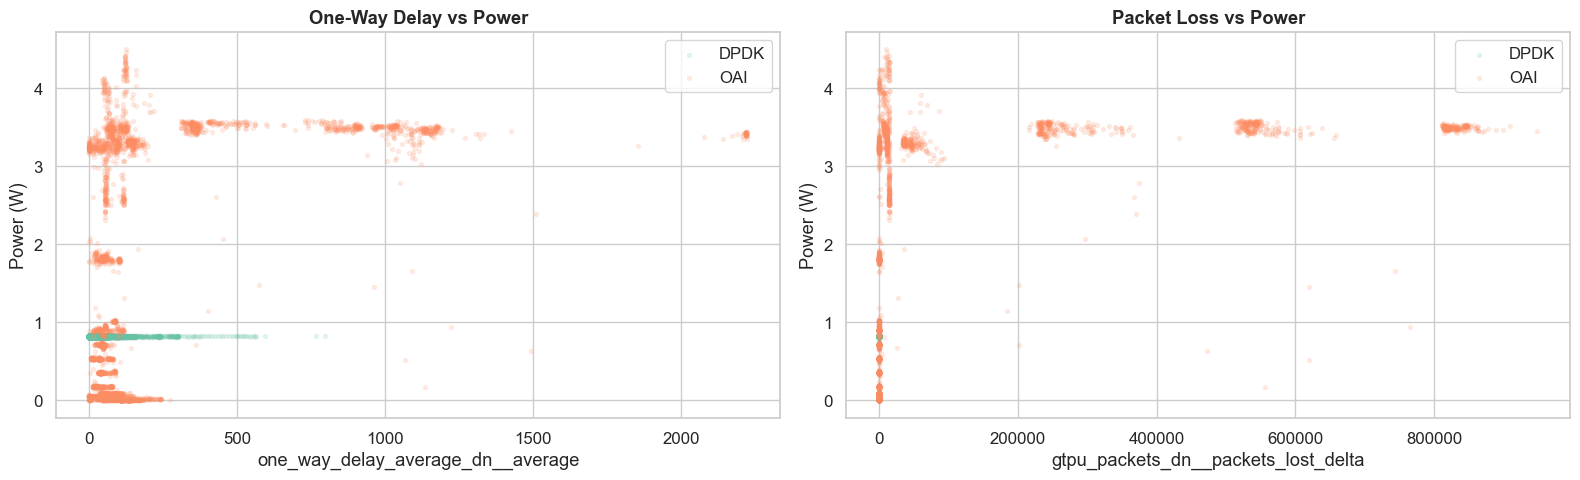

In [13]:
delay_cols = [c for c in df.columns if "delay" in c.lower() and c in features_only]
loss_cols = [c for c in df.columns if "lost" in c.lower() and c in features_only]

print("Delay features:", delay_cols)
print("Loss features:", loss_cols)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Delay vs power
ax = axes[0]
delay_col = "one_way_delay_average_dn__average" if "one_way_delay_average_dn__average" in df.columns else delay_cols[0]
for label, subset, color in [("DPDK", dpdk, "C0"), ("OAI", oai, "C1")]:
    vals = subset[[delay_col, "power_watts"]].dropna()
    ax.scatter(vals[delay_col], vals["power_watts"], alpha=0.15, s=8, label=label, color=color)
ax.set_xlabel(f"{delay_col}")
ax.set_ylabel("Power (W)")
ax.set_title("One-Way Delay vs Power", fontweight="bold")
ax.legend()

# Loss vs power
ax = axes[1]
loss_col = "gtpu_packets_dn__packets_lost_delta" if "gtpu_packets_dn__packets_lost_delta" in df.columns else None
if loss_col:
    for label, subset, color in [("DPDK", dpdk, "C0"), ("OAI", oai, "C1")]:
        vals = subset[[loss_col, "power_watts"]].dropna()
        ax.scatter(vals[loss_col], vals["power_watts"], alpha=0.15, s=8, label=label, color=color)
    ax.set_xlabel(f"{loss_col}")
    ax.set_ylabel("Power (W)")
    ax.set_title("Packet Loss vs Power", fontweight="bold")
    ax.legend()

    # What fraction of rows have non-zero loss?
    for label, subset in [("DPDK", dpdk), ("OAI", oai)]:
        nonzero = (subset[loss_col] > 0).sum()
        print(f"  {label}: {nonzero}/{len(subset)} rows ({100*nonzero/len(subset):.1f}%) have packet loss")

fig.tight_layout()
plt.show()

## 10. Derived Features Sanity Check

Verify that the engineered features make physical sense.

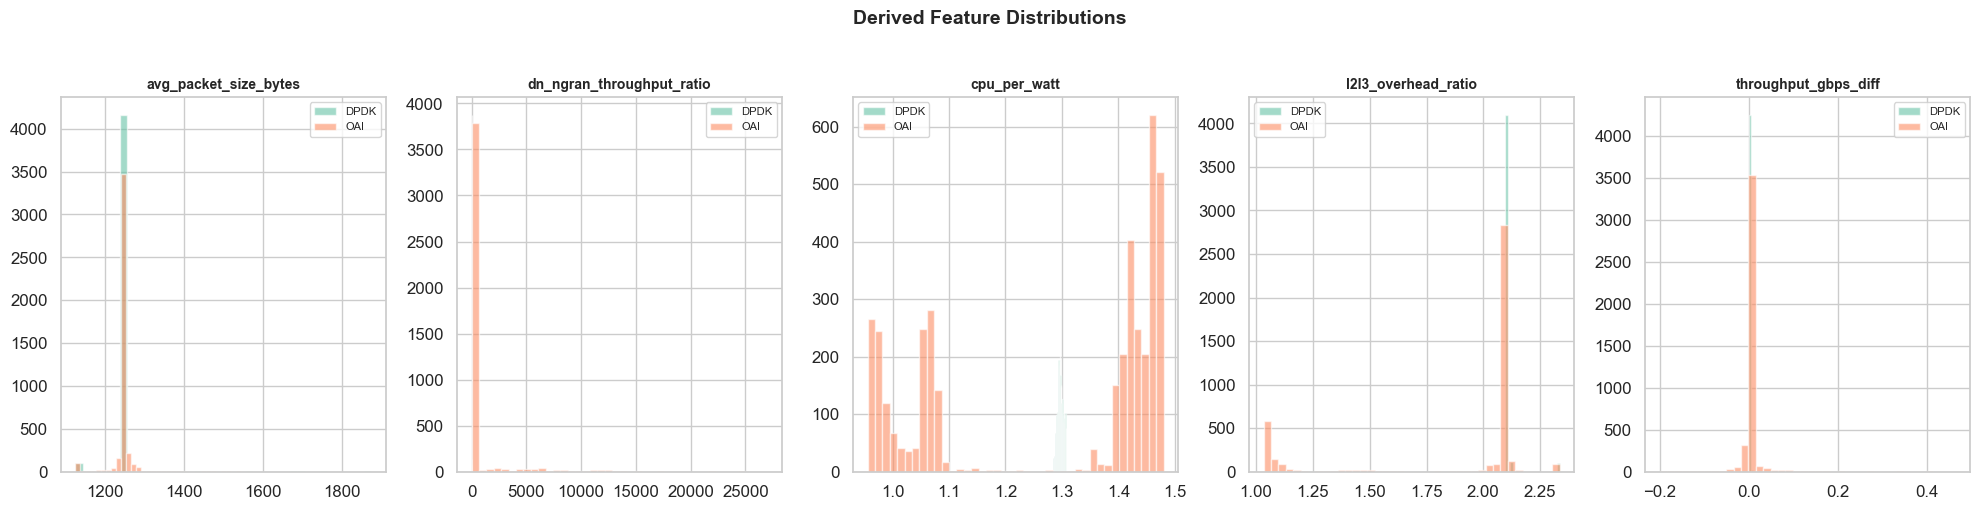


avg_packet_size_bytes (expected ~1250):
  mean=1259, median=1250, std=110


In [14]:
derived = ["avg_packet_size_bytes", "dn_ngran_throughput_ratio",
           "cpu_per_watt", "l2l3_overhead_ratio", "throughput_gbps_diff"]
derived = [c for c in derived if c in df.columns]

fig, axes = plt.subplots(1, len(derived), figsize=(4*len(derived), 5))
if len(derived) == 1:
    axes = [axes]

for ax, col in zip(axes, derived):
    for label, subset, color in [("DPDK", dpdk, "C0"), ("OAI", oai, "C1")]:
        vals = subset[col].dropna()
        # Clip extreme outliers
        q01, q99 = vals.quantile(0.01), vals.quantile(0.99)
        vals = vals[(vals >= q01) & (vals <= q99)]
        ax.hist(vals, bins=40, alpha=0.6, label=label, color=color, edgecolor="white")
    ax.set_title(col, fontweight="bold", fontsize=10)
    ax.legend(fontsize=8)

fig.suptitle("Derived Feature Distributions", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

# Sanity: packet size should be ~1250 bytes (our test configuration)
if "avg_packet_size_bytes" in df.columns:
    valid = df["avg_packet_size_bytes"].dropna()
    valid = valid[(valid > 0) & (valid < 10000)]
    print(f"\navg_packet_size_bytes (expected ~1250):")
    print(f"  mean={valid.mean():.0f}, median={valid.median():.0f}, std={valid.std():.0f}")

## 11. Pairplot â€” Key Features vs Power

Focused pairplot of the most important features against the primary target.

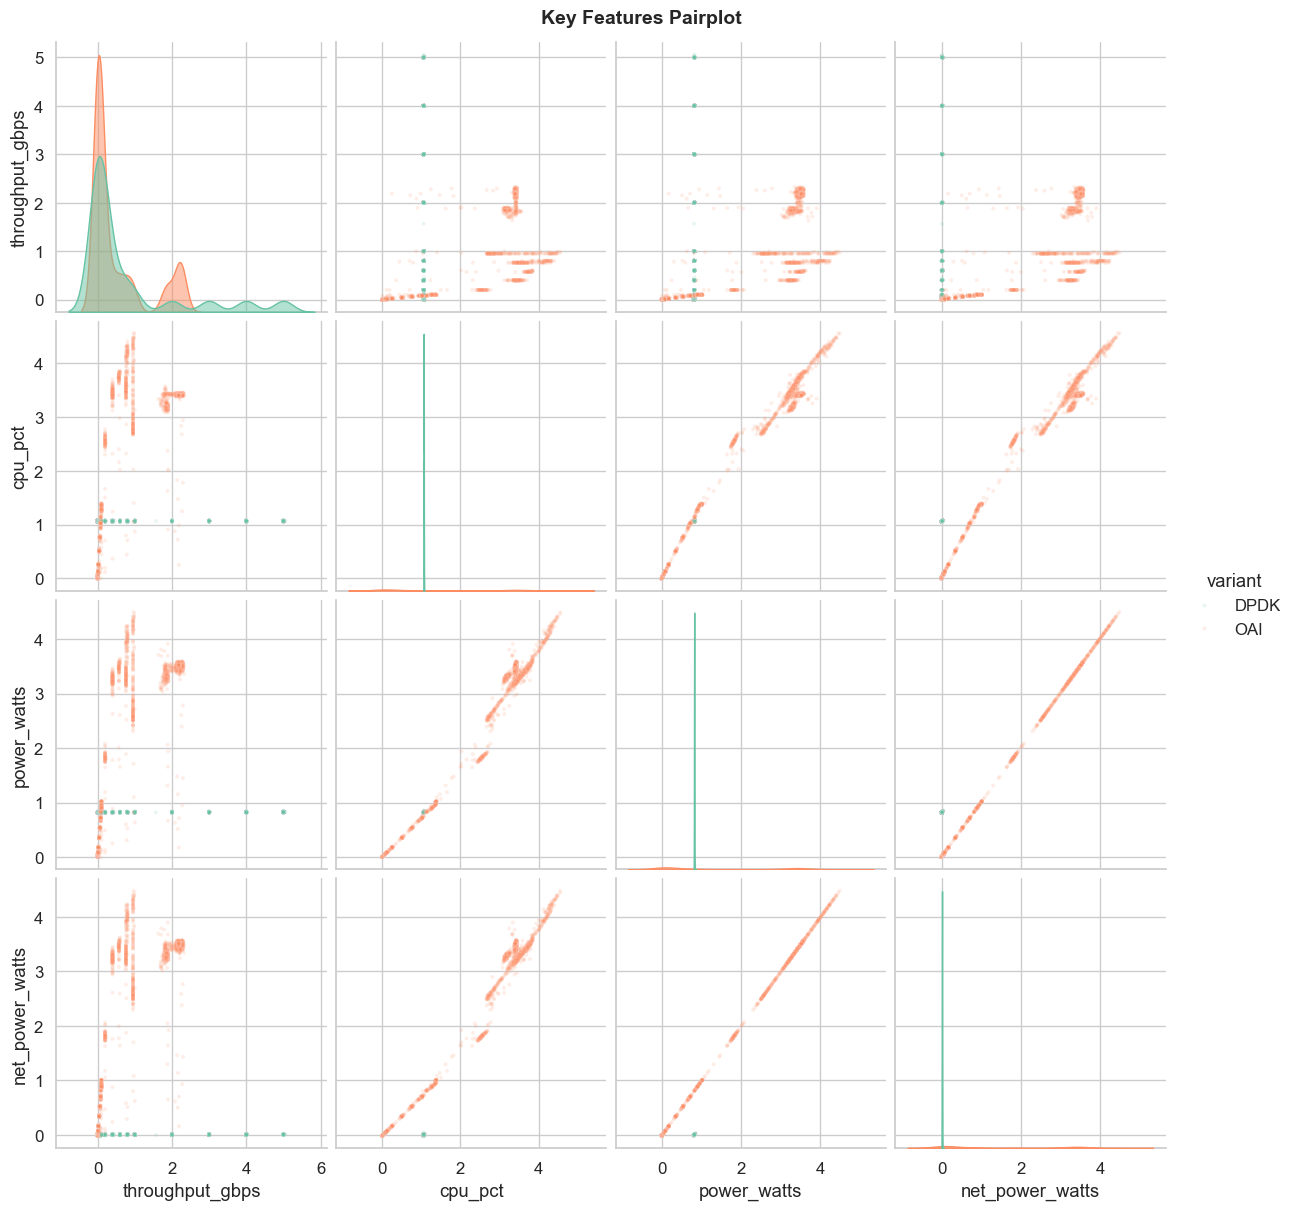

In [15]:
key_features = ["throughput_gbps", "cpu_pct", "power_watts", "net_power_watts"]
key_features = [c for c in key_features if c in df.columns]

plot_df = df[key_features + ["is_dpdk"]].dropna().copy()
plot_df["variant"] = plot_df["is_dpdk"].map({1: "DPDK", 0: "OAI"})

g = sns.pairplot(plot_df, hue="variant", vars=key_features,
                 plot_kws={"alpha": 0.15, "s": 8},
                 diag_kws={"alpha": 0.5},
                 height=3)
g.figure.suptitle("Key Features Pairplot", fontsize=14, fontweight="bold", y=1.01)
plt.show()

## 12. Rolling Features â€” Do They Add Information?

Compare correlation of raw vs rolling features with power to check if temporal smoothing helps.

In [16]:
roll_cols = [c for c in df.columns if "_roll_" in c or c == "throughput_gbps_diff"]
raw_counterparts = ["throughput_gbps", "power_watts"]

compare_cols = raw_counterparts + roll_cols
compare_df = df[compare_cols + ["power_watts", "net_power_watts", "is_dpdk"]].copy()

print("Correlation with power_watts (pooled):")
print("-" * 55)
for c in compare_cols:
    if c in ("power_watts", "net_power_watts"):
        continue
    r = df[c].corr(df["power_watts"])
    print(f"  {r:+.4f}  {c}")

print(f"\nCorrelation with power_watts (DPDK only):")
print("-" * 55)
for c in compare_cols:
    if c in ("power_watts", "net_power_watts"):
        continue
    r = dpdk[c].corr(dpdk["power_watts"])
    print(f"  {r:+.4f}  {c}")

print(f"\nCorrelation with power_watts (OAI only):")
print("-" * 55)
for c in compare_cols:
    if c in ("power_watts", "net_power_watts"):
        continue
    r = oai[c].corr(oai["power_watts"])
    print(f"  {r:+.4f}  {c}")

Correlation with power_watts (pooled):
-------------------------------------------------------
  +0.3509  throughput_gbps
  +0.9820  power_watts_roll_mean_30s
  +0.4573  power_watts_roll_std_30s
  +0.9979  power_watts_roll_max_30s
  +0.3521  throughput_gbps_roll_mean_30s
  +0.1597  throughput_gbps_roll_std_30s
  +0.3605  throughput_gbps_roll_max_30s
  +0.0019  throughput_gbps_diff

Correlation with power_watts (DPDK only):
-------------------------------------------------------
  +0.4590  throughput_gbps
  +0.7175  power_watts_roll_mean_30s
  +0.0934  power_watts_roll_std_30s
  +0.5558  power_watts_roll_max_30s
  +0.4555  throughput_gbps_roll_mean_30s
  +0.1869  throughput_gbps_roll_std_30s
  +0.4594  throughput_gbps_roll_max_30s
  +0.0588  throughput_gbps_diff

Correlation with power_watts (OAI only):
-------------------------------------------------------
  +0.8085  throughput_gbps
  +0.9811  power_watts_roll_mean_30s
  +0.4134  power_watts_roll_std_30s
  +0.9977  power_watts_roll_ma

## 13. Data Leakage Check

Verify that no feature is a trivial transformation of the target (would give misleadingly perfect model performance).

In [17]:
# Check for features with suspiciously high correlation to ALL targets
# (would indicate data leakage â€” the feature IS the target)
print("Features with |r| > 0.95 with any target:\n")
leakage_found = False
for feat in features_only:
    for t in targets:
        r = abs(df[feat].corr(df[t]))
        if r > 0.95:
            print(f"  WARNING: {feat} <-> {t}:  r={r:.4f}")
            leakage_found = True

if not leakage_found:
    print("  None found â€” no obvious leakage.")

# Also check: are rolling power features leaking the target?
print("\nRolling power features vs power_watts:")
for c in [c for c in df.columns if "power_watts_roll" in c]:
    r = df[c].corr(df["power_watts"])
    flag = "  <-- EXPECTED (smoothed version of target)" if r > 0.9 else ""
    print(f"  r={r:.4f}  {c}{flag}")

print("\nNote: power_watts rolling features are derived FROM the target.")
print("If we predict power_watts, these MUST be excluded from the feature set.")
print("The train.py script should handle this by separating target from features.")

Features with |r| > 0.95 with any target:


Rolling power features vs power_watts:
  r=0.9820  power_watts_roll_mean_30s  <-- EXPECTED (smoothed version of target)
  r=0.4573  power_watts_roll_std_30s
  r=0.9979  power_watts_roll_max_30s  <-- EXPECTED (smoothed version of target)

Note: power_watts rolling features are derived FROM the target.
If we predict power_watts, these MUST be excluded from the feature set.
The train.py script should handle this by separating target from features.


## 14. Summary & Modelling Recommendations

Key findings to inform `train.py`:

1. **Target choice**: `power_watts` is the most direct and honest target. SEC metrics are useful for interpretation but have extreme outliers at low throughput.

2. **DPDK vs OAI**: Fundamentally different regimes â€” DPDK has near-constant power (~0.82W) while OAI scales from ~0.02W to ~4.5W. A single model will learn `is_dpdk` as the most important feature. Consider training separate per-variant models.

3. **Rolling power features**: These are derived from the target â€” must be excluded when predicting `power_watts` or `net_power_watts`. Rolling *throughput* features are safe.

4. **Leakage columns to exclude per target**:
   - If target = `power_watts`: drop `net_power_watts`, `power_watts_roll_*`, `cpu_per_watt`, `*_delay_power_product`
   - If target = `net_power_watts`: drop `power_watts`, `power_watts_roll_*`, `cpu_per_watt`, `*_delay_power_product`
   - If target = `sec_total` or `sec_net`: drop all other SEC variants, `power_watts`, `net_power_watts`, `power_watts_roll_*`

5. **Feature highlights**: throughput, CPU, L2/L3 overhead ratio, rolling throughput std (captures variability), and delay metrics are the most promising predictors.

In [18]:
# Final feature matrix summary
print(f"Feature matrix: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"  DPDK: {len(dpdk)} rows ({100*len(dpdk)/len(df):.1f}%)")
print(f"  OAI:  {len(oai)} rows ({100*len(oai)/len(df):.1f}%)")
print(f"\nTargets: {targets}")
print(f"Features (excl. targets): {len(features_only)}")
print(f"  Canonical traffic:  {len([c for c in features_only if 'gtpu' in c or 'user_plane' in c])}")
print(f"  Delay/jitter:       {len([c for c in features_only if 'delay' in c.lower() or 'jitter' in c.lower()])}")
print(f"  Loss:               {len([c for c in features_only if 'lost' in c.lower()])}")
print(f"  Rolling:            {len([c for c in features_only if '_roll_' in c or '_diff' in c])}")
print(f"  Derived:            {len([c for c in features_only if c in ['avg_packet_size_bytes','dn_ngran_throughput_ratio','cpu_per_watt','l2l3_overhead_ratio']])}")
print(f"  Power/CPU:          {len([c for c in features_only if c in ['cpu_pct','idle_cpu_pct']])}")
print(f"  Categorical:        {len([c for c in features_only if c == 'is_dpdk'])}")

Feature matrix: 8781 rows x 44 columns
  DPDK: 4388 rows (50.0%)
  OAI:  4393 rows (50.0%)

Targets: ['power_watts', 'net_power_watts', 'sec_total', 'sec_net']
Features (excl. targets): 40
  Canonical traffic:  12
  Delay/jitter:       12
  Loss:               2
  Rolling:            7
  Derived:            4
  Power/CPU:          2
  Categorical:        1


## 15. UPF Variant Profiles

A side-by-side characterisation of the two UPF data-plane implementations
under identical LoadCore traffic scenarios.

In [19]:
# ── Variant profile summary table ────────────────────────────────────────
import warnings, textwrap
warnings.filterwarnings("ignore", category=FutureWarning)

def variant_profile(sub, label):
    """Compute a dict of summary statistics for one variant."""
    tp = sub["throughput_gbps"]
    pw = sub["power_watts"]
    npw = sub["net_power_watts"]
    cpu = sub["cpu_pct"]
    loss = sub["gtpu_packets_dn__packets_lost_delta"]
    dl_delay = sub["downlink_one_way_delay_distribution__weighted_mean_delay_us"].dropna()
    ul_delay = sub["uplink_data_one_way_delay_distribution__weighted_mean_delay_us"].dropna()
    jitter_dn = sub["delay_variation_jitter_average_dn__avg_us"]
    jitter_ran = sub["delay_variation_jitter_average_ran__avg_us"]
    oh = sub["l2l3_overhead_ratio"].dropna()

    high_tp = sub[tp > 1.0]
    low_tp  = sub[(tp > 0.01) & (tp < 0.1)]

    return {
        "Variant": label,
        "Samples": len(sub),
        # Power
        "Power min (W)": pw.min(),
        "Power max (W)": pw.max(),
        "Power mean (W)": pw.mean(),
        "Power std (W)": pw.std(),
        "Dynamic range (W)": pw.max() - pw.min(),
        "Net power mean (W)": npw.mean(),
        # CPU
        "CPU mean (%)": cpu.mean(),
        "CPU max (%)": cpu.max(),
        "Idle CPU (%)": sub["idle_cpu_pct"].iloc[0],
        # Throughput
        "Max throughput (Gbps)": tp.max(),
        "Mean throughput (Gbps)": tp.mean(),
        "Median throughput (Gbps)": tp.median(),
        # Loss
        "Packet loss rows (%)": 100 * (loss > 0).mean(),
        # Delay
        "DL delay mean (us)": dl_delay.mean(),
        "DL delay max (us)": dl_delay.max(),
        "UL delay mean (us)": ul_delay.mean(),
        "RAN jitter mean (us)": jitter_ran.mean(),
        "RAN jitter max (us)": jitter_ran.max(),
        # SEC at high throughput
        "SEC_total @>1Gbps (J/Gb)": high_tp["sec_total"].median() if len(high_tp) else np.nan,
        "SEC_net @>1Gbps (J/Gb)": high_tp["sec_net"].median() if len(high_tp) else np.nan,
        # Overhead
        "L2/L3 overhead ratio": oh.mean(),
    }

profiles = pd.DataFrame([
    variant_profile(dpdk, "DPDK"),
    variant_profile(oai, "OAI"),
]).set_index("Variant").T

profiles.style.format("{:.4f}", na_rep="—").set_caption(
    "Table: UPF Variant Profiles — Key Performance and Energy Metrics"
)

Variant,DPDK,OAI
Samples,4388.0000,4393.0000
Power min (W),0.8071,0.0000
Power max (W),0.8590,4.4973
Power mean (W),0.8206,1.4350
Power std (W),0.0046,1.5269
Dynamic range (W),0.0518,4.4973
Net power mean (W),0.0013,1.4185
CPU mean (%),1.0643,1.5486
CPU max (%),1.0790,4.5543
Idle CPU (%),1.0642,0.0180


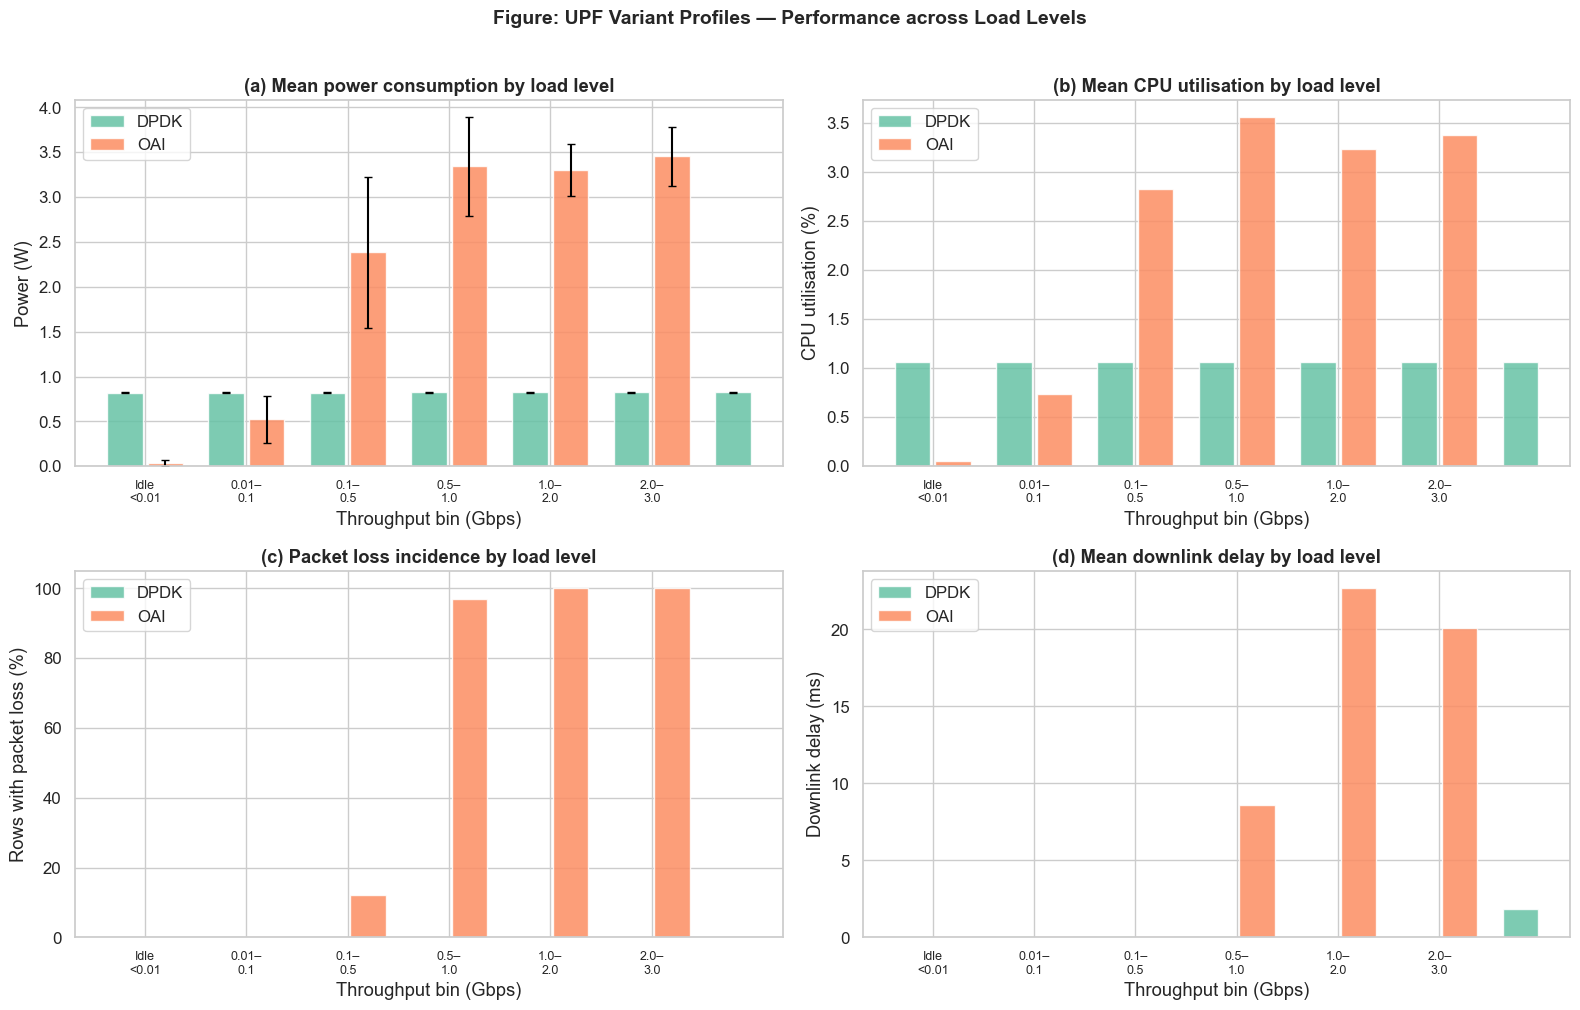

In [20]:
# ── Power–throughput binned comparison ────────────────────────────────────
tp_bins = [0, 0.01, 0.1, 0.5, 1.0, 2.0, 3.0, 5.1]
tp_labels = ["Idle\n<0.01", "0.01–\n0.1", "0.1–\n0.5", "0.5–\n1.0", "1.0–\n2.0", "2.0–\n3.0", "3.0–\n5.0"]

records = []
for label, sub in [("DPDK", dpdk), ("OAI", oai)]:
    sub = sub.copy()
    sub["tp_bin"] = pd.cut(sub["throughput_gbps"], bins=tp_bins, labels=tp_labels)
    for b in tp_labels:
        bsub = sub[sub["tp_bin"] == b]
        if len(bsub) == 0:
            continue
        records.append({
            "Variant": label, "Throughput bin": b,
            "n": len(bsub),
            "Power mean (W)": bsub["power_watts"].mean(),
            "Power std (W)": bsub["power_watts"].std(),
            "Loss (%)": 100 * (bsub["gtpu_packets_dn__packets_lost_delta"] > 0).mean(),
            "DL delay (us)": bsub["downlink_one_way_delay_distribution__weighted_mean_delay_us"].mean(),
            "CPU (%)": bsub["cpu_pct"].mean(),
        })
binned = pd.DataFrame(records)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# (a) Power vs throughput bin
ax = axes[0, 0]
for i, (label, color) in enumerate([("DPDK", "C0"), ("OAI", "C1")]):
    d = binned[binned["Variant"] == label]
    x = np.arange(len(d))
    offset = -0.2 + i * 0.4
    bars = ax.bar(x + offset, d["Power mean (W)"], 0.35, yerr=d["Power std (W)"],
                  label=label, color=color, alpha=0.85, capsize=3)
    ax.set_xticks(x)
    ax.set_xticklabels(d["Throughput bin"], fontsize=9)
ax.set_ylabel("Power (W)")
ax.set_xlabel("Throughput bin (Gbps)")
ax.set_title("(a) Mean power consumption by load level", fontweight="bold")
ax.legend()

# (b) CPU vs throughput bin
ax = axes[0, 1]
for i, (label, color) in enumerate([("DPDK", "C0"), ("OAI", "C1")]):
    d = binned[binned["Variant"] == label]
    x = np.arange(len(d))
    offset = -0.2 + i * 0.4
    ax.bar(x + offset, d["CPU (%)"], 0.35, label=label, color=color, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(d["Throughput bin"], fontsize=9)
ax.set_ylabel("CPU utilisation (%)")
ax.set_xlabel("Throughput bin (Gbps)")
ax.set_title("(b) Mean CPU utilisation by load level", fontweight="bold")
ax.legend()

# (c) Packet loss vs throughput bin
ax = axes[1, 0]
for i, (label, color) in enumerate([("DPDK", "C0"), ("OAI", "C1")]):
    d = binned[binned["Variant"] == label]
    x = np.arange(len(d))
    offset = -0.2 + i * 0.4
    ax.bar(x + offset, d["Loss (%)"], 0.35, label=label, color=color, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(d["Throughput bin"], fontsize=9)
ax.set_ylabel("Rows with packet loss (%)")
ax.set_xlabel("Throughput bin (Gbps)")
ax.set_title("(c) Packet loss incidence by load level", fontweight="bold")
ax.legend()

# (d) Delay vs throughput bin
ax = axes[1, 1]
for i, (label, color) in enumerate([("DPDK", "C0"), ("OAI", "C1")]):
    d = binned[binned["Variant"] == label]
    x = np.arange(len(d))
    offset = -0.2 + i * 0.4
    ax.bar(x + offset, d["DL delay (us)"] / 1000, 0.35, label=label, color=color, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(d["Throughput bin"], fontsize=9)
ax.set_ylabel("Downlink delay (ms)")
ax.set_xlabel("Throughput bin (Gbps)")
ax.set_title("(d) Mean downlink delay by load level", fontweight="bold")
ax.legend()

fig.suptitle("Figure: UPF Variant Profiles — Performance across Load Levels",
             fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

## 16. OAI Saturation Analysis

The OAI UPF exhibits a clear saturation regime where packet loss becomes
pervasive. This section determines the onset throughput, characterises the
transition, and quantifies the performance degradation.

In [21]:
# ── Fine-grained OAI saturation analysis ─────────────────────────────────
oai_sorted = oai.sort_values("throughput_gbps").copy()

# Fine bins for the transition region
fine_bins = np.arange(0, 2.6, 0.05)
oai_sorted["tp_fine"] = pd.cut(oai_sorted["throughput_gbps"], bins=fine_bins)

sat = oai_sorted.groupby("tp_fine", observed=True).agg(
    n=("power_watts", "count"),
    loss_frac=("gtpu_packets_dn__packets_lost_delta", lambda x: (x > 0).mean()),
    loss_mean=("gtpu_packets_dn__packets_lost_delta", lambda x: x[x > 0].mean() if (x > 0).any() else 0),
    dl_delay=("downlink_one_way_delay_distribution__weighted_mean_delay_us", "mean"),
    power=("power_watts", "mean"),
    cpu=("cpu_pct", "mean"),
).reset_index()
sat["tp_mid"] = sat["tp_fine"].apply(lambda x: x.mid)
sat = sat[sat["n"] >= 5]  # need enough samples

# Find saturation onset: first bin where loss_frac > 5%
onset = sat[sat["loss_frac"] > 0.05]
if len(onset) > 0:
    onset_tp = onset["tp_mid"].iloc[0]
    print(f"OAI saturation onset: ~{onset_tp:.2f} Gbps (first bin with >5% loss)")
else:
    onset_tp = None
    print("No clear saturation onset found")

# Find the bin where loss > 50%
half_loss = sat[sat["loss_frac"] > 0.50]
if len(half_loss) > 0:
    print(f"50% loss reached at:  ~{half_loss['tp_mid'].iloc[0]:.2f} Gbps")

# Find where loss is 100%
full_loss = sat[sat["loss_frac"] > 0.99]
if len(full_loss) > 0:
    print(f"~100% loss from:      ~{full_loss['tp_mid'].iloc[0]:.2f} Gbps")

# Power at saturation
pre_sat = oai_sorted[oai_sorted["throughput_gbps"] < 0.3]
post_sat = oai_sorted[oai_sorted["throughput_gbps"] > 0.5]
print(f"\nPower before saturation (<0.3 Gbps): {pre_sat['power_watts'].mean():.3f} W")
print(f"Power after saturation  (>0.5 Gbps): {post_sat['power_watts'].mean():.3f} W")
print(f"Power plateau (>1.0 Gbps):           {oai_sorted[oai_sorted['throughput_gbps'] > 1.0]['power_watts'].mean():.3f} W")

OAI saturation onset: ~0.17 Gbps (first bin with >5% loss)
50% loss reached at:  ~0.57 Gbps
~100% loss from:      ~0.57 Gbps

Power before saturation (<0.3 Gbps): 0.338 W
Power after saturation  (>0.5 Gbps): 3.378 W
Power plateau (>1.0 Gbps):           3.406 W


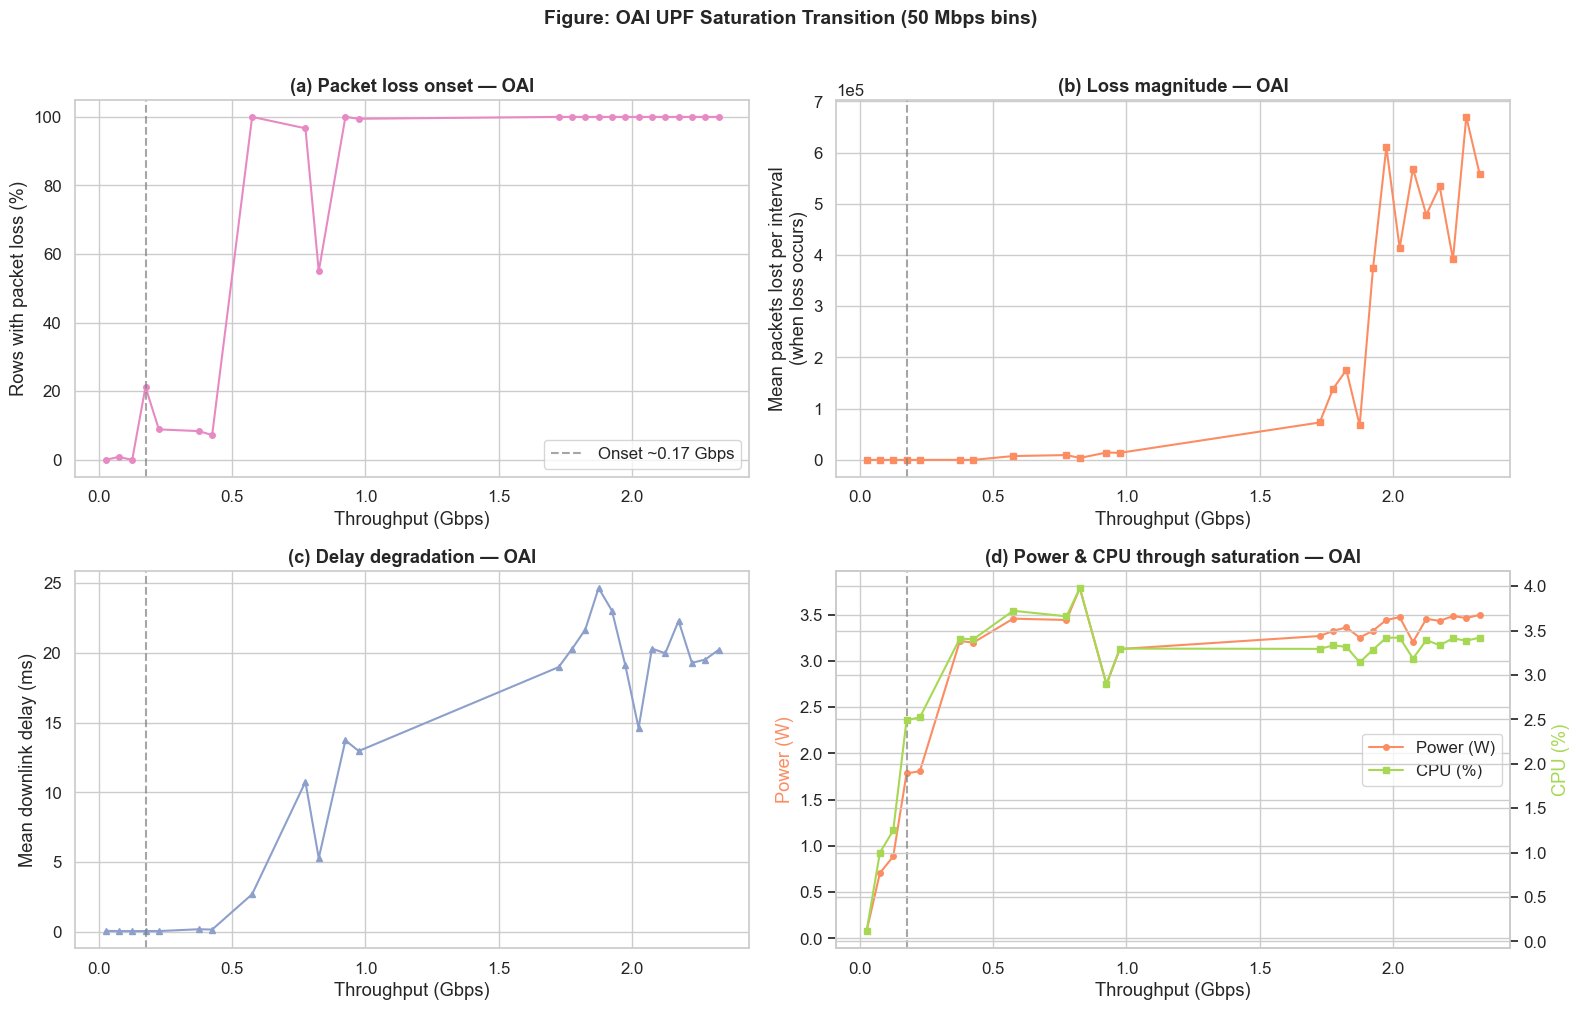

In [22]:
# ── OAI saturation transition plot ────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# (a) Packet loss fraction vs throughput
ax = axes[0, 0]
ax.plot(sat["tp_mid"], sat["loss_frac"] * 100, "o-", color="C3", markersize=4)
if onset_tp is not None:
    ax.axvline(onset_tp, ls="--", color="grey", alpha=0.7, label=f"Onset ~{onset_tp:.2f} Gbps")
ax.set_xlabel("Throughput (Gbps)")
ax.set_ylabel("Rows with packet loss (%)")
ax.set_title("(a) Packet loss onset — OAI", fontweight="bold")
ax.legend()
ax.set_ylim(-5, 105)

# (b) Mean packets lost vs throughput
ax = axes[0, 1]
ax.plot(sat["tp_mid"], sat["loss_mean"], "s-", color="C1", markersize=4)
if onset_tp is not None:
    ax.axvline(onset_tp, ls="--", color="grey", alpha=0.7)
ax.set_xlabel("Throughput (Gbps)")
ax.set_ylabel("Mean packets lost per interval\n(when loss occurs)")
ax.set_title("(b) Loss magnitude — OAI", fontweight="bold")
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

# (c) Downlink delay vs throughput
ax = axes[1, 0]
ax.plot(sat["tp_mid"], sat["dl_delay"] / 1000, "^-", color="C2", markersize=4)
if onset_tp is not None:
    ax.axvline(onset_tp, ls="--", color="grey", alpha=0.7)
ax.set_xlabel("Throughput (Gbps)")
ax.set_ylabel("Mean downlink delay (ms)")
ax.set_title("(c) Delay degradation — OAI", fontweight="bold")

# (d) Power & CPU vs throughput (dual axis)
ax = axes[1, 1]
ax2 = ax.twinx()
ax.plot(sat["tp_mid"], sat["power"], "o-", color="C1", markersize=4, label="Power (W)")
ax2.plot(sat["tp_mid"], sat["cpu"], "s-", color="C4", markersize=4, label="CPU (%)")
if onset_tp is not None:
    ax.axvline(onset_tp, ls="--", color="grey", alpha=0.7)
ax.set_xlabel("Throughput (Gbps)")
ax.set_ylabel("Power (W)", color="C1")
ax2.set_ylabel("CPU (%)", color="C4")
ax.set_title("(d) Power & CPU through saturation — OAI", fontweight="bold")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="center right")

fig.suptitle("Figure: OAI UPF Saturation Transition (50 Mbps bins)",
             fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

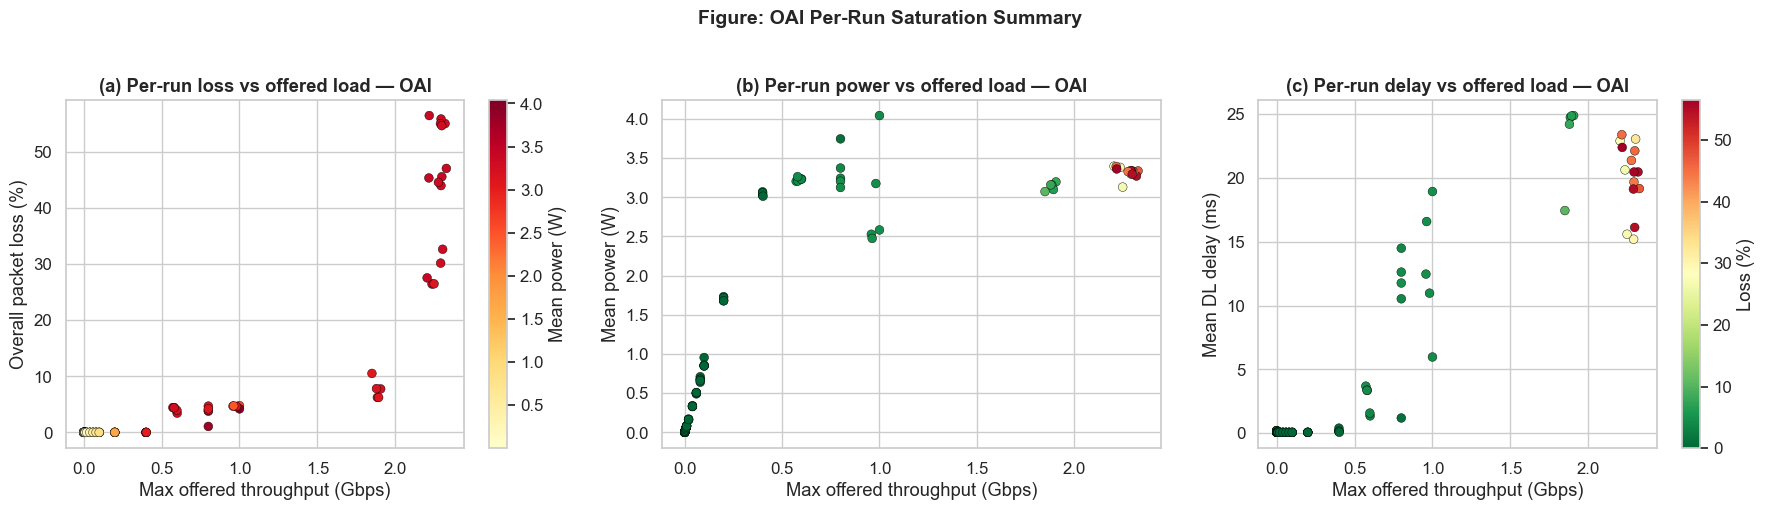


OAI runs without any loss: 61/110
  Max throughput in lossless runs: 0.100 Gbps
  Min throughput in lossy runs:    0.060 Gbps

Safe operating range: 0 – 0.10 Gbps


In [23]:
# ── Per-run saturation: scatter of max throughput vs loss for OAI ─────────
merged = pd.read_csv("../data/interim/merged.csv")
oai_merged = merged[merged["dataplane"] == "userspaceapplication"].copy()

run_stats = oai_merged.groupby("run_dir").agg(
    max_tp_gbps=("gtpu_kbitss_dn__kbits_rx_s", lambda x: x.max() / 1e6),
    mean_power_w=("power_microwatts", lambda x: x.mean() / 1e6),
    total_lost=("gtpu_packets_dn__packets_lost_delta", "sum"),
    total_rx=("gtpu_packets_dn__packets_rx_delta", "sum"),
    mean_dl_delay=("downlink_one_way_delay_distribution__weighted_mean_delay_us", "mean"),
    n_samples=("power_microwatts", "count"),
).reset_index()
run_stats["loss_pct"] = 100 * run_stats["total_lost"] / (run_stats["total_rx"] + run_stats["total_lost"]).replace(0, np.nan)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Per-run loss vs max throughput
ax = axes[0]
sc = ax.scatter(run_stats["max_tp_gbps"], run_stats["loss_pct"],
                c=run_stats["mean_power_w"], cmap="YlOrRd", s=40, edgecolors="k", linewidths=0.3)
plt.colorbar(sc, ax=ax, label="Mean power (W)")
ax.set_xlabel("Max offered throughput (Gbps)")
ax.set_ylabel("Overall packet loss (%)")
ax.set_title("(a) Per-run loss vs offered load — OAI", fontweight="bold")

# Per-run power vs max throughput
ax = axes[1]
ax.scatter(run_stats["max_tp_gbps"], run_stats["mean_power_w"],
           c=run_stats["loss_pct"], cmap="RdYlGn_r", s=40, edgecolors="k", linewidths=0.3)
ax.set_xlabel("Max offered throughput (Gbps)")
ax.set_ylabel("Mean power (W)")
ax.set_title("(b) Per-run power vs offered load — OAI", fontweight="bold")

# Per-run delay vs max throughput
ax = axes[2]
sc2 = ax.scatter(run_stats["max_tp_gbps"], run_stats["mean_dl_delay"] / 1000,
                 c=run_stats["loss_pct"], cmap="RdYlGn_r", s=40, edgecolors="k", linewidths=0.3)
plt.colorbar(sc2, ax=ax, label="Loss (%)")
ax.set_xlabel("Max offered throughput (Gbps)")
ax.set_ylabel("Mean DL delay (ms)")
ax.set_title("(c) Per-run delay vs offered load — OAI", fontweight="bold")

fig.suptitle("Figure: OAI Per-Run Saturation Summary", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

# Summary
no_loss_runs = run_stats[run_stats["total_lost"] == 0]
loss_runs = run_stats[run_stats["total_lost"] > 0]
print(f"\nOAI runs without any loss: {len(no_loss_runs)}/{len(run_stats)}")
print(f"  Max throughput in lossless runs: {no_loss_runs['max_tp_gbps'].max():.3f} Gbps")
print(f"  Min throughput in lossy runs:    {loss_runs['max_tp_gbps'].min():.3f} Gbps")
print(f"\nSafe operating range: 0 – {no_loss_runs['max_tp_gbps'].max():.2f} Gbps")